# Enron Email Corpus — Exploratory Data Analysis

A principal-DS-level exploration of the Enron email corpus (20K curated emails
from 15 key custodians). We cover:

1. **Corpus Overview** — dimensions, completeness, data quality
2. **Temporal Patterns** — volume over time, day-of-week/hour heatmap, crisis alignment
3. **Communication Network** — power brokers, cliques, degree distribution
4. **Content & Thread Analysis** — body length, thread depth, subject clustering
5. **Recipient Patterns** — TO/CC/BCC usage, broadcast detection
6. **Data Quality Audit** — nulls, duplicates, parsing artifacts

---
**Source tables:** `serverless_8e8gyh_catalog.graphrag_enron.{emails, participants, threads}`

## 0. Data Acquisition & Preprocessing

The Enron email corpus is a public dataset of ~517K emails released by the
Federal Energy Regulatory Commission during the Enron investigation. We download
the raw archive from CMU, parse RFC-2822 headers, filter to **15 key custodians**
(executives and persons of interest), deduplicate on `message_id`, and assign
thread IDs by normalized subject line.

**Pipeline:** CMU tar.gz → extract → parse headers → custodian filter → dedup → thread → Delta tables

In [0]:
import pyspark.sql.functions as F

CATALOG = 'serverless_8e8gyh_catalog'
SCHEMA = 'graphrag_enron'
VOLUME_PATH = f'/Volumes/{CATALOG}/{SCHEMA}/raw'
CMU_URL = 'https://www.cs.cmu.edu/~enron/enron_mail_20150507.tar.gz'

# 15 key custodians — executives and persons of interest in the Enron investigation
KEY_CUSTODIANS = [
    'lay-k', 'skilling-j', 'fastow-a', 'delainey-d', 'dasovich-j',
    'kaminski-v', 'kitchen-l', 'shackleton-s', 'germany-c', 'bass-e',
    'allen-p', 'arnold-j', 'beck-s', 'blair-l', 'campbell-l',
]
MAX_EMAILS = 20_000

# ── Idempotency check: skip download if tables already populated ──
_existing = spark.table(f'{CATALOG}.{SCHEMA}.emails').count()
if _existing > 0:
    print(f'✓ Tables already populated ({_existing:,} emails) — skipping download.')
    print(f'  Delete the table and re-run to refresh: DROP TABLE {CATALOG}.{SCHEMA}.emails')
    _SKIP_LOAD = True
else:
    print(f'Tables empty — will download and process from CMU archive.')
    _SKIP_LOAD = False

✓ Tables already populated (20,000 emails) — skipping download.
  Delete the table and re-run to refresh: DROP TABLE serverless_8e8gyh_catalog.graphrag_enron.emails


In [0]:
if not _SKIP_LOAD:
    import io, tarfile, requests
    from pyspark.sql.types import StructType, StructField, StringType

    print(f'Downloading {CMU_URL} (~423 MB)...')
    resp = requests.get(CMU_URL, stream=True, timeout=600)
    resp.raise_for_status()
    chunks = []
    for chunk in resp.iter_content(chunk_size=1024 * 1024):
        chunks.append(chunk)
    raw_bytes = b''.join(chunks)
    del chunks
    print(f'Downloaded {len(raw_bytes) / 1024 / 1024:.0f} MB')

    # Extract all email files from the tar archive
    # NOTE: In this archive every email file ends with '.' (e.g., maildir/lay-k/inbox/1.)
    # — a naive endswith('.') filter would discard ALL emails.
    print('Extracting emails from archive...')
    rows = []
    with tarfile.open(fileobj=io.BytesIO(raw_bytes), mode='r:gz') as tar:
        for member in tar:
            if member.isfile():
                try:
                    f = tar.extractfile(member)
                    if f is None:
                        continue
                    raw = f.read().decode('utf-8', errors='replace')
                    rows.append((member.name, raw))
                except Exception:
                    continue
    del raw_bytes
    print(f'Extracted {len(rows):,} raw email files')

    # Persist as a Spark DataFrame for downstream processing
    raw_schema = StructType([StructField('file', StringType()), StructField('message', StringType())])
    raw_df = spark.createDataFrame(rows, raw_schema)
    del rows
else:
    print('Skipped — using existing data.')

Skipped — using existing data.


In [0]:
# ── Show what a single raw email looks like before parsing ──
if not _SKIP_LOAD:
    sample_raw = raw_df.limit(1).collect()[0]
    print(f'File path: {sample_raw.file}')
    print('-' * 70)
    # Show first 1500 chars to reveal RFC-2822 header + body structure
    print(sample_raw.message[:1500])
    print('...')
    print(f'\nTotal raw email count: {raw_df.count():,}')
else:
    # Read one raw email from CSV if it still exists in the volume
    try:
        _sample = (spark.read.option('header', 'true').option('multiLine', 'true')
                   .option('escape', '"').csv(f'{VOLUME_PATH}/emails.csv').limit(1).collect()[0])
        print(f'File path: {_sample.file}')
        print('-' * 70)
        print(_sample.message[:1500])
        print('...')
    except Exception:
        print('Raw CSV no longer in volume — showing parsed table sample instead.')
        display(spark.table(f'{CATALOG}.{SCHEMA}.emails').limit(3))

File path: maildir/blair-l/personnel___promotions/1.
----------------------------------------------------------------------
Message-ID: <8012132.1075853083164.JavaMail.evans@thyme>
Date: Fri, 14 Sep 2001 14:05:43 -0700 (PDT)
From: fran.fagan@enron.com
To: lynn.blair@enron.com
Subject: FW: Promotions and Transfers- Gas Logistics
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Fagan, Fran </O=ENRON/OU=NA/CN=RECIPIENTS/CN=FFAGAN>
X-To: Blair, Lynn </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Lblair>
X-cc: 
X-bcc: 
X-Folder: \\LBLAIR (Non-Privileged)\\Blair, Lynn\\Personnel - Promotions
X-Origin: Blair-L
X-FileName: LBLAIR (Non-Privileged).pst





Name			New Title				Effective Date			Mid Year promotion Yes/No

Floyd, Jodie		Sr Cust Svc Rep (no change)		7/16/01				No

Buehler, Craig		Sr Mkt/Sup Analyst (no change)		7/16/01				No

Wagoner, Mike		Team Advisor - Gas Control		7/1/01				No

Clapper, Karen		Sr Cust Svc Rep			8/1/01				Yes

Greaney, Chris	

In [0]:
if not _SKIP_LOAD:
    import email as email_lib
    import re
    from datetime import datetime as _dt
    from pyspark.sql.types import ArrayType, TimestampType

    # ── UDF: parse raw RFC-2822 message into structured fields ──
    def _parse_email(raw_message: str):
        if not raw_message:
            return None
        msg = email_lib.message_from_string(raw_message)

        def _addrs(field):
            val = msg.get(field, '')
            return [a.strip() for a in val.split(',') if a.strip()] if val else []

        # Parse date with timezone-aware + naive formats
        date_str = re.sub(r'\s*\(.*?\)\s*$', '', msg.get('Date', '')).strip()
        parsed_date = None
        for fmt in ('%a, %d %b %Y %H:%M:%S %z', '%a, %d %b %Y %H:%M:%S',
                     '%d %b %Y %H:%M:%S %z', '%d %b %Y %H:%M:%S'):
            try:
                parsed_date = _dt.strptime(date_str, fmt)
                break
            except ValueError:
                continue

        # Extract body and strip forwarded/reply boilerplate
        body = msg.get_payload(decode=False) or ''
        if isinstance(body, bytes):
            body = body.decode('utf-8', errors='replace')
        body = re.sub(r'-{3,}\s*Original Message\s*-{3,}.*', '', body, flags=re.DOTALL | re.IGNORECASE)
        body = re.sub(r'-{3,}\s*Forwarded by\s.*?-{3,}', '', body, flags=re.DOTALL | re.IGNORECASE)

        return {
            'message_id': msg.get('Message-ID', ''),
            'date': parsed_date,
            'sender': msg.get('From', ''),
            'to_recipients': _addrs('To'),
            'cc_recipients': _addrs('Cc'),
            'bcc_recipients': _addrs('Bcc'),
            'subject': msg.get('Subject', ''),
            'body': body.strip()[:8000],
            'x_from': msg.get('X-From', ''),
            'x_to': msg.get('X-To', ''),
            'in_reply_to': msg.get('In-Reply-To', ''),
        }

    from pyspark.sql.types import StructType, StructField, StringType, TimestampType, ArrayType
    _email_schema = StructType([
        StructField('message_id', StringType()), StructField('date', TimestampType()),
        StructField('sender', StringType()), StructField('to_recipients', ArrayType(StringType())),
        StructField('cc_recipients', ArrayType(StringType())), StructField('bcc_recipients', ArrayType(StringType())),
        StructField('subject', StringType()), StructField('body', StringType()),
        StructField('x_from', StringType()), StructField('x_to', StringType()),
        StructField('in_reply_to', StringType()),
    ])
    _parse_udf = F.udf(_parse_email, _email_schema)

    # Parse → filter by custodian mailbox path → dedup on message_id
    custodian_re = '|'.join(KEY_CUSTODIANS)
    parsed_df = (
        raw_df
        .withColumn('parsed', _parse_udf(F.col('message')))
        .select(F.col('file').alias('mailbox_path'), 'parsed.*')
        .filter(F.col('message_id').isNotNull())
        .filter(F.col('body').isNotNull() & (F.length('body') > 10))
    )
    filtered_df = (
        parsed_df
        .filter(F.col('mailbox_path').rlike(f'({custodian_re})'))
        .dropDuplicates(['message_id'])
        .limit(MAX_EMAILS)
    )
    print(f'After parsing:    {parsed_df.count():>10,} emails')
    print(f'After filtering:  {filtered_df.count():>10,} emails  (15 custodians, deduped, capped at {MAX_EMAILS:,})')
else:
    print('Skipped — using existing data.')

Skipped — using existing data.


In [0]:
if not _SKIP_LOAD:
    # ── Thread assignment by normalized subject line ──
    # Strip Re:/Fw:/Fwd: prefixes to group replies into the same thread
    emails_final = (
        filtered_df
        .withColumn('subject_clean', F.lower(F.regexp_replace(F.col('subject'), r'^(?:re|fw|fwd)\s*:\s*', '')))
        .withColumn('thread_id', F.concat(F.lit('subj:'), F.col('subject_clean')))
        .select('message_id', 'date', 'sender', 'to_recipients', 'cc_recipients',
                'bcc_recipients', 'subject', 'body', 'thread_id', 'mailbox_path', 'x_from', 'x_to')
    )

    # ── Write emails ──
    emails_final.write.format('delta').mode('overwrite').option('overwriteSchema', 'true') \
        .saveAsTable(f'{CATALOG}.{SCHEMA}.emails')

    # ── Write participants (union of senders + all recipient fields) ──
    senders = emails_final.select(F.col('sender').alias('email_address'), F.col('x_from').alias('display_name')).distinct()
    recips  = emails_final.select(F.explode('to_recipients').alias('email_address')).withColumn('display_name', F.lit(None).cast('string')).distinct()
    cc_addr = emails_final.select(F.explode('cc_recipients').alias('email_address')).withColumn('display_name', F.lit(None).cast('string')).distinct()
    participants_df = (
        senders.unionByName(recips).unionByName(cc_addr)
        .groupBy('email_address').agg(F.first('display_name', ignorenulls=True).alias('display_name'))
        .withColumn('name_normalized', F.regexp_replace(F.coalesce('display_name', 'email_address'), r'\s+', ' '))
        .withColumn('department', F.regexp_extract('email_address', r'@(\w+)', 1))
    )
    participants_df.write.format('delta').mode('overwrite').option('overwriteSchema', 'true') \
        .saveAsTable(f'{CATALOG}.{SCHEMA}.participants')

    # ── Write threads (aggregate emails into conversation threads) ──
    threads_df = (
        emails_final.groupBy('thread_id').agg(
            F.count('*').alias('email_count'),
            F.min('date').alias('first_email_date'),
            F.max('date').alias('last_email_date'),
            F.first('subject').alias('subject'),
            F.collect_set('sender').alias('participants'),
            F.concat_ws('\n\n---\n\n',
                F.transform(
                    F.array_sort(F.collect_list(F.struct('date', 'sender', 'body'))),
                    lambda x: F.concat(F.lit('From: '), x['sender'], F.lit('\n'), x['body'])
                )).alias('thread_text'),
        ).withColumn('thread_text_preview', F.substring('thread_text', 1, 2000))
    )
    threads_df.write.format('delta').mode('overwrite').option('overwriteSchema', 'true') \
        .saveAsTable(f'{CATALOG}.{SCHEMA}.threads')

    _e = spark.table(f'{CATALOG}.{SCHEMA}.emails').count()
    _p = spark.table(f'{CATALOG}.{SCHEMA}.participants').count()
    _t = spark.table(f'{CATALOG}.{SCHEMA}.threads').count()
    print(f'✓ Emails:       {_e:>8,}')
    print(f'✓ Participants: {_p:>8,}')
    print(f'✓ Threads:      {_t:>8,}')
else:
    print('Skipped — using existing data.')

Skipped — using existing data.


In [0]:
# ── Quick look at the three output tables ──
print('═' * 70)
print('EMAILS (first 5 rows)')
print('═' * 70)
display(
    spark.table(f'{CATALOG}.{SCHEMA}.emails')
    .select('message_id', 'date', 'sender', 'subject',
            F.size('to_recipients').alias('to_count'),
            F.size('cc_recipients').alias('cc_count'),
            F.length('body').alias('body_len'), 'thread_id')
    .orderBy('date')
    .limit(5)
)

print('\n' + '═' * 70)
print('PARTICIPANTS (first 5 rows)')
print('═' * 70)
display(spark.table(f'{CATALOG}.{SCHEMA}.participants').limit(5))

print('\n' + '═' * 70)
print('THREADS — top 5 by email count')
print('═' * 70)
display(
    spark.table(f'{CATALOG}.{SCHEMA}.threads')
    .select('thread_id', 'email_count', 'first_email_date', 'last_email_date',
            'subject', F.size('participants').alias('participant_count'))
    .orderBy(F.desc('email_count'))
    .limit(5)
)

══════════════════════════════════════════════════════════════════════
EMAILS (first 5 rows)
══════════════════════════════════════════════════════════════════════


message_id,date,sender,subject,to_count,cc_count,body_len,thread_id
<25602594.1075859213611.JavaMail.evans@thyme>,0001-12-19T06:21:55.000Z,enron_update@concureworkplace.com,<> - jd121101,1,0,371,subj:<> - jd121101
<5040207.1075859214398.JavaMail.evans@thyme>,0001-12-22T06:30:50.000Z,enron_update@concureworkplace.com,<> - jd121101,1,0,371,subj:<> - jd121101
<19382699.1075859214421.JavaMail.evans@thyme>,0001-12-25T06:25:50.000Z,enron_update@concureworkplace.com,<> - jd121101,1,0,371,subj:<> - jd121101
<19712154.1075859109500.JavaMail.evans@thyme>,0001-12-28T16:45:27.000Z,enron_update@concureworkplace.com,<> - Kay Chapman,1,0,331,subj:<> - kay chapman
<26875093.1075859109545.JavaMail.evans@thyme>,0001-12-31T13:26:54.000Z,enron_update@concureworkplace.com,<> - David W. Delainey,1,0,407,subj:<> - david w. delainey



══════════════════════════════════════════════════════════════════════
PARTICIPANTS (first 5 rows)
══════════════════════════════════════════════════════════════════════


email_address,display_name,name_normalized,department
bob.stevens@enron.com,"Stevens, Bob","Stevens, Bob",enron
vjw@cleanpower.org,V. John White,V. John White,cleanpower
janet.mcdaniel@enron.com,"McDaniel, Janet","McDaniel, Janet",enron
jeff.nieland@enron.com,Jeff Nieland,Jeff Nieland,enron
cashflowebusiness@aol.com,CashFlowEBusiness@aol.com ()@ENRON,CashFlowEBusiness@aol.com ()@ENRON,aol



══════════════════════════════════════════════════════════════════════
THREADS — top 5 by email count
══════════════════════════════════════════════════════════════════════


thread_id,email_count,first_email_date,last_email_date,subject,participant_count
subj:,1181,1999-11-05T13:53:00.000Z,2002-01-18T17:20:50.000Z,,96
subj:re:,408,2000-04-09T17:11:00.000Z,2002-01-02T23:47:47.000Z,Re:,55
subj:approval for reviewer,75,2000-11-01T17:03:00.000Z,2000-11-21T08:48:00.000Z,Approval for reviewer,2
subj:staff mtg. conference room eb4102,49,2001-06-27T23:02:00.000Z,2001-06-27T23:02:00.000Z,Staff Mtg. Conference room EB4102,1
subj:team leader mtg. conference room eb4102,46,2001-06-27T23:02:00.000Z,2001-06-27T23:02:00.000Z,Team Leader Mtg. Conference room EB4102,1


In [0]:
# ── Additional imports for visualization (CATALOG / SCHEMA defined in Section 0) ──
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

emails = spark.table(f'{CATALOG}.{SCHEMA}.emails')
participants = spark.table(f'{CATALOG}.{SCHEMA}.participants')
threads = spark.table(f'{CATALOG}.{SCHEMA}.threads')

print(f'Emails:       {emails.count():>10,}')
print(f'Participants: {participants.count():>10,}')
print(f'Threads:      {threads.count():>10,}')

Emails:           20,000
Participants:      8,380
Threads:           8,301


## 1. Corpus Overview & Data Quality Audit

Before any analysis, understand the shape of the data: column completeness,
date range, and potential parsing failures.

In [0]:
# ── Column-level completeness for emails table ──
total = emails.count()

stats = []
for col_name in emails.columns:
    col = F.col(col_name)
    dtype_str = str(emails.schema[col_name].dataType).lower()
    if 'array' in dtype_str:
        null_count = emails.filter(col.isNull() | (F.size(col) == 0)).count()
    elif 'string' in dtype_str:
        null_count = emails.filter(col.isNull() | (col == '') | (col == 'None')).count()
    else:
        null_count = emails.filter(col.isNull()).count()
    stats.append((col_name, null_count, round(100 * null_count / total, 2)))

stats_df = spark.createDataFrame(stats, ['column', 'null_or_empty', 'pct_missing'])
display(stats_df.orderBy(F.desc('pct_missing')))

column,null_or_empty,pct_missing
cc_recipients,14478,72.39
bcc_recipients,14478,72.39
to_recipients,1419,7.09
x_to,1194,5.97
subject,1181,5.91
message_id,1,0.01
date,0,0.0
sender,0,0.0
body,0,0.0
thread_id,0,0.0


In [0]:
# ── Key summary statistics ──
summary = emails.agg(
    F.count('*').alias('total_emails'),
    F.countDistinct('sender').alias('unique_senders'),
    F.countDistinct('thread_id').alias('unique_threads'),
    F.date_format(F.min('date'), 'yyyy-MM-dd HH:mm:ss').alias('earliest_email'),
    F.date_format(F.max('date'), 'yyyy-MM-dd HH:mm:ss').alias('latest_email'),
    F.avg(F.length('body')).alias('avg_body_length'),
    F.expr('percentile_approx(length(body), 0.5)').alias('median_body_length'),
    F.avg(F.size('to_recipients')).alias('avg_to_count'),
    F.avg(F.size('cc_recipients')).alias('avg_cc_count'),
).toPandas()

for col in summary.columns:
    val = summary[col].iloc[0]
    if isinstance(val, float):
        print(f'{col:25s}: {val:,.1f}')
    else:
        print(f'{col:25s}: {val}')

total_emails             : 20000
unique_senders           : 1326
unique_threads           : 8301
earliest_email           : 0001-12-19 06:21:55
latest_email             : 2002-09-22 16:42:25
avg_body_length          : 780.0
median_body_length       : 353
avg_to_count             : 6.5
avg_cc_count             : 1.5


In [0]:
# ── Identify dates outside reasonable Enron range (1998-2002) ──
date_dist = emails.select(
    F.year('date').alias('year'),
    F.month('date').alias('month'),
).groupBy('year').agg(
    F.count('*').alias('count')
).orderBy('year').toPandas()

print('Email count by year:')
print(date_dist.to_string(index=False))

anomalous = emails.filter(
    (F.year('date') < 1998) | (F.year('date') > 2003) | F.col('date').isNull()
).count()
print(f'\nAnomalous/null dates: {anomalous:,} ({100*anomalous/total:.1f}%)')

Email count by year:
 year  count
    1      5
 1980     17
 1998      2
 1999    272
 2000   7840
 2001  11776
 2002     88

Anomalous/null dates: 22 (0.1%)


## 2. Temporal Patterns

Enron's crisis unfolded late 2001. We expect email volume to spike during
crisis months and the activity to drop sharply after bankruptcy (Dec 2001).
We also look for day-of-week and hour-of-day patterns that reveal work culture.

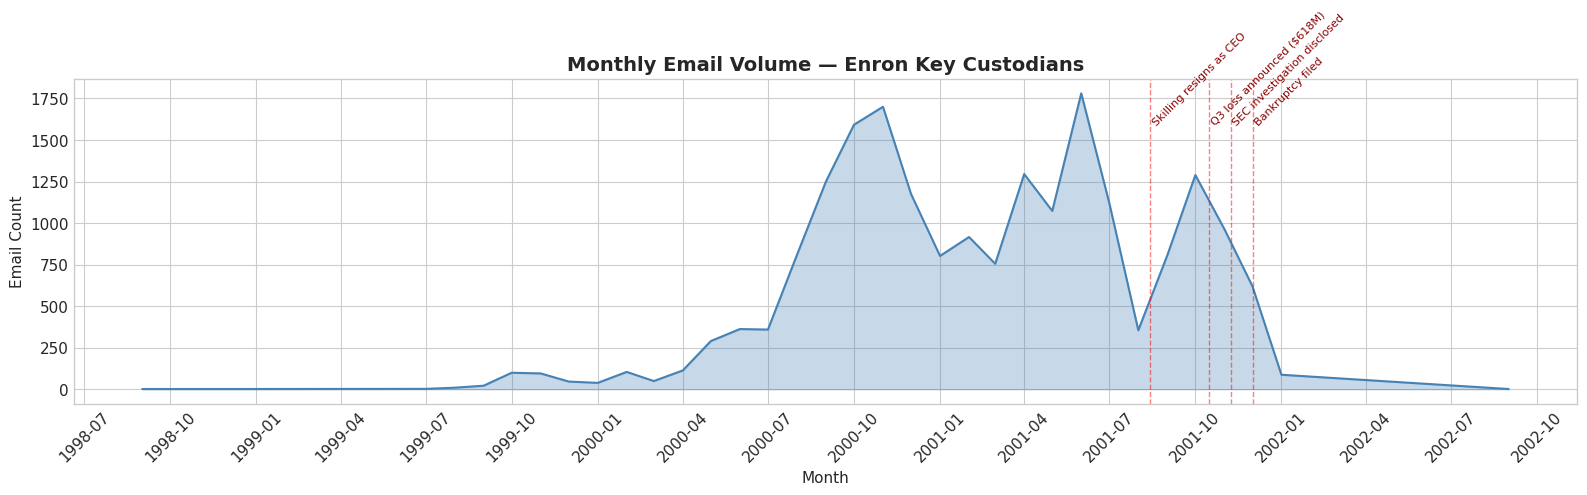

In [0]:
# ── Monthly email volume with Enron crisis timeline ──
monthly = (
    emails
    .filter((F.year('date') >= 1998) & (F.year('date') <= 2003))
    .withColumn('month', F.date_trunc('month', 'date'))
    .groupBy('month')
    .agg(F.count('*').alias('email_count'))
    .orderBy('month')
    .withColumn('month', F.date_format('month', 'yyyy-MM-dd'))
    .toPandas()
)
monthly['month'] = pd.to_datetime(monthly['month'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(monthly['month'], monthly['email_count'], alpha=0.3, color='steelblue')
ax.plot(monthly['month'], monthly['email_count'], color='steelblue', linewidth=1.5)

# Annotate key Enron events
events = {
    '2001-08-14': 'Skilling resigns as CEO',
    '2001-10-16': 'Q3 loss announced ($618M)',
    '2001-11-08': 'SEC investigation disclosed',
    '2001-12-02': 'Bankruptcy filed',
}
for date_str, label in events.items():
    d = datetime.strptime(date_str, '%Y-%m-%d')
    ax.axvline(d, color='red', alpha=0.5, linestyle='--', linewidth=1)
    ax.annotate(label, xy=(d, ax.get_ylim()[1]*0.85), fontsize=8,
                rotation=45, ha='left', color='darkred')

ax.set_title('Monthly Email Volume — Enron Key Custodians', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Email Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

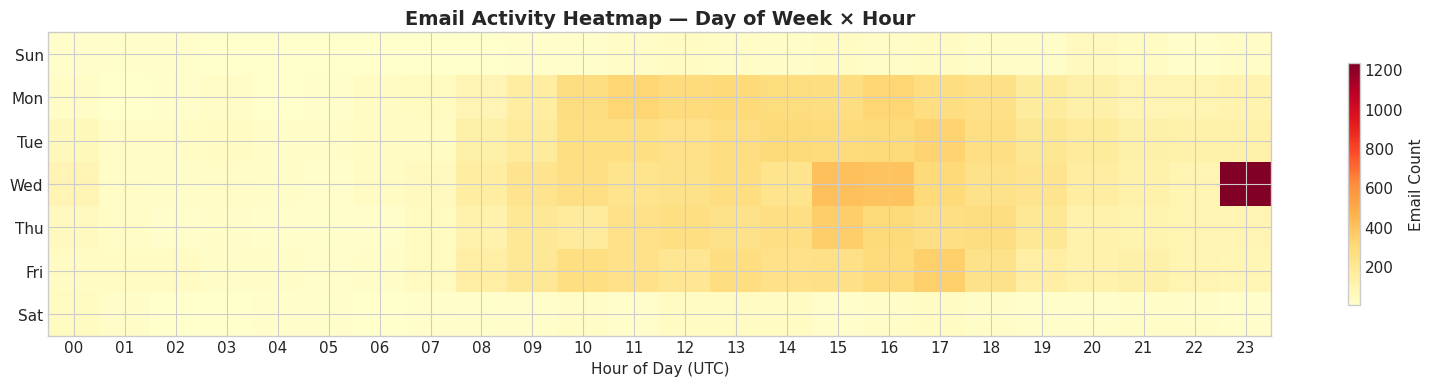

In [0]:
# ── Day-of-week × hour-of-day heatmap ──
heatmap_data = (
    emails
    .withColumn('dow', F.dayofweek('date'))       # 1=Sun, 7=Sat
    .withColumn('hour', F.hour('date'))
    .groupBy('dow', 'hour')
    .agg(F.count('*').alias('count'))
    .toPandas()
)

pivot = heatmap_data.pivot_table(index='dow', columns='hour', values='count', fill_value=0)
day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(7))
ax.set_yticklabels(day_labels)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.set_xlabel('Hour of Day (UTC)')
ax.set_title('Email Activity Heatmap — Day of Week × Hour', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Email Count', shrink=0.8)
plt.tight_layout()
plt.show()

In [0]:
# ── Pre-crisis vs crisis vs post-crisis comparison ──
period_df = (
    emails
    .withColumn('period', F.when(F.col('date') < '2001-08-01', 'Pre-Crisis (before Aug 2001)')
                          .when(F.col('date') < '2002-01-01', 'Crisis (Aug-Dec 2001)')
                          .otherwise('Post-Bankruptcy (2002+)'))
    .groupBy('period')
    .agg(
        F.count('*').alias('email_count'),
        F.countDistinct('sender').alias('active_senders'),
        F.avg(F.length('body')).alias('avg_body_length'),
        F.avg(F.size('to_recipients') + F.size('cc_recipients')).alias('avg_recipients'),
    )
    .orderBy('period')
)
display(period_df)

period,email_count,active_senders,avg_body_length,avg_recipients
Crisis (Aug-Dec 2001),4034,758,518.6279127416956,9.121467526028756
Post-Bankruptcy (2002+),88,58,717.3522727272727,2.5
Pre-Crisis (before Aug 2001),15878,707,846.7592266028468,7.7935508250409375


## 3. Communication Network Analysis

Who are the power brokers? Which sender-recipient pairs dominate?
Does the degree distribution follow a power law (as expected in organizational
communication networks)?

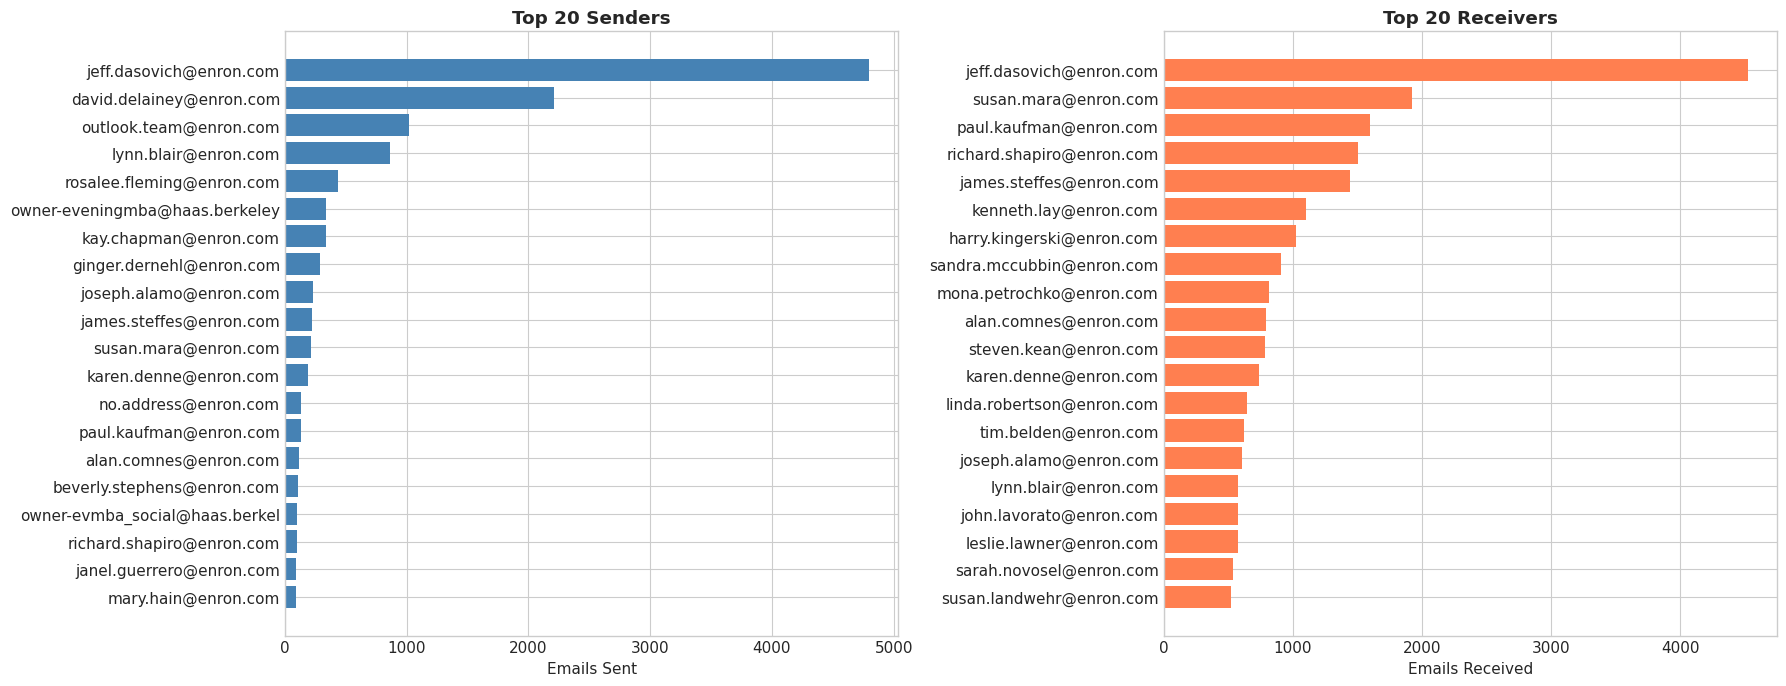

In [0]:
# ── Top senders ──
top_senders = (
    emails.groupBy('sender')
    .agg(F.count('*').alias('sent'))
    .orderBy(F.desc('sent'))
    .limit(20)
    .toPandas()
)

# ── Top receivers ──
top_receivers = (
    emails.select(F.explode('to_recipients').alias('recipient'))
    .groupBy('recipient')
    .agg(F.count('*').alias('received'))
    .orderBy(F.desc('received'))
    .limit(20)
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Senders
ax1.barh(top_senders['sender'].str[:30], top_senders['sent'], color='steelblue')
ax1.set_xlabel('Emails Sent')
ax1.set_title('Top 20 Senders', fontweight='bold')
ax1.invert_yaxis()

# Receivers
ax2.barh(top_receivers['recipient'].str[:30], top_receivers['received'], color='coral')
ax2.set_xlabel('Emails Received')
ax2.set_title('Top 20 Receivers', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [0]:
# ── Top sender→recipient pairs (communication highways) ──
edges = (
    emails
    .select('sender', F.explode('to_recipients').alias('recipient'))
    .filter(F.col('sender') != F.col('recipient'))
    .groupBy('sender', 'recipient')
    .agg(F.count('*').alias('email_count'))
    .orderBy(F.desc('email_count'))
    .limit(25)
)
display(edges)

sender,recipient,email_count
jeff.dasovich@enron.com,paul.kaufman@enron.com,542
jeff.dasovich@enron.com,susan.mara@enron.com,522
jeff.dasovich@enron.com,james.steffes@enron.com,467
jeff.dasovich@enron.com,richard.shapiro@enron.com,465
jeff.dasovich@enron.com,karen.denne@enron.com,413
owner-eveningmba@haas.berkeley.edu,eveningmba@haas.berkeley.edu,318
jeff.dasovich@enron.com,skean@enron.com,290
ginger.dernehl@enron.com,jeff.dasovich@enron.com,273
jeff.dasovich@enron.com,harry.kingerski@enron.com,256
jeff.dasovich@enron.com,sandra.mccubbin@enron.com,254


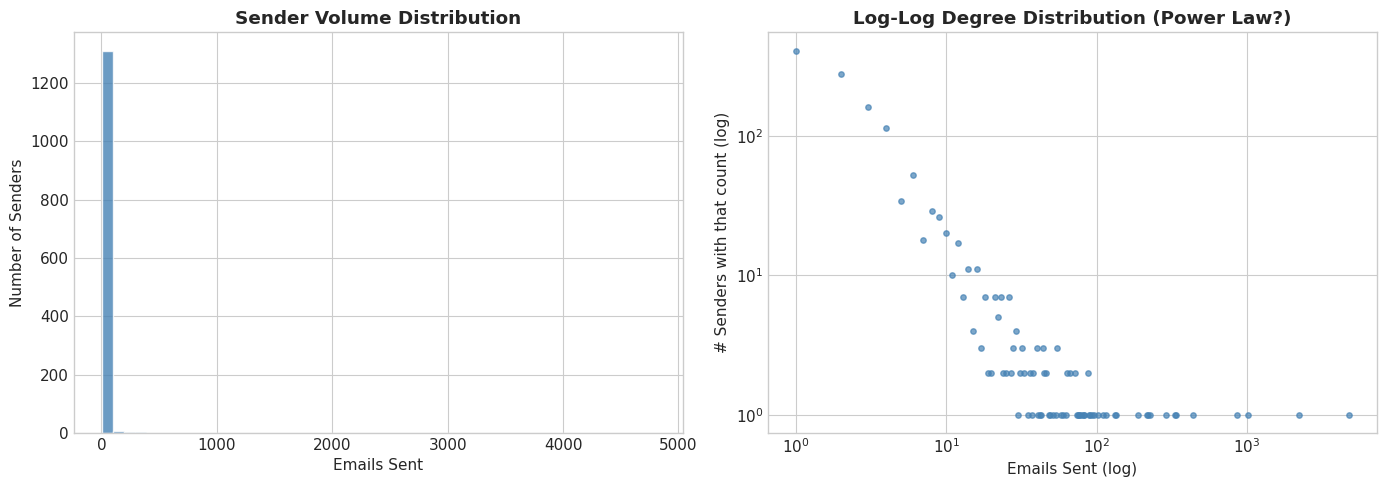

Gini coefficient of sender volume: 0.843 (0=equal, 1=max inequality)


In [0]:
# ── Degree distribution — does it follow a power law? ──
sender_counts = (
    emails.groupBy('sender')
    .agg(F.count('*').alias('sent'))
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale histogram
ax1.hist(sender_counts['sent'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.set_xlabel('Emails Sent')
ax1.set_ylabel('Number of Senders')
ax1.set_title('Sender Volume Distribution', fontweight='bold')

# Log-log scale (power law test)
from collections import Counter
counts = Counter(sender_counts['sent'].values)
x, y = zip(*sorted(counts.items()))
ax2.scatter(x, y, s=15, alpha=0.7, color='steelblue')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Emails Sent (log)')
ax2.set_ylabel('# Senders with that count (log)')
ax2.set_title('Log-Log Degree Distribution (Power Law?)', fontweight='bold')

plt.tight_layout()
plt.show()

# Gini coefficient for inequality measure
sorted_vals = np.sort(sender_counts['sent'].values)
n = len(sorted_vals)
gini = (2 * np.sum((np.arange(1, n+1)) * sorted_vals) - (n + 1) * np.sum(sorted_vals)) / (n * np.sum(sorted_vals))
print(f'Gini coefficient of sender volume: {gini:.3f} (0=equal, 1=max inequality)')

## 4. Content & Thread Analysis

Explore email body length distributions, thread depth (how many emails per
conversation), and subject-line patterns. For a corpus destined for GraphRAG,
thread depth and content richness directly impact entity extraction quality.

Body length distribution (characters):
min       11.00000
p25      154.00000
median   353.00000
p75      921.00000
p95     2891.00000
max     8000.00000
mean     780.00575


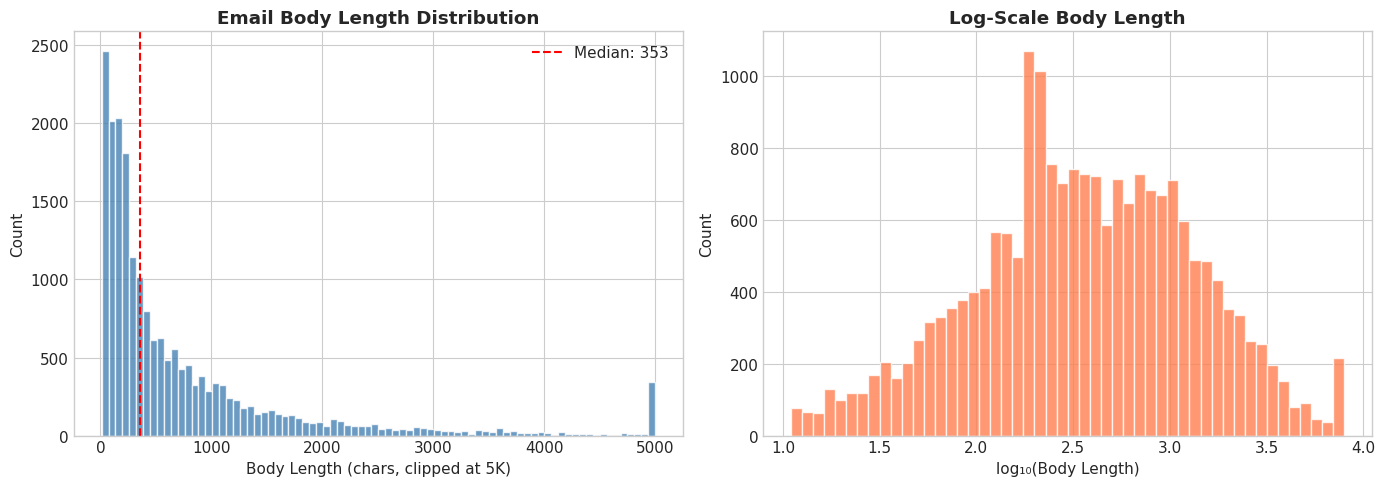

In [0]:
# ── Body length distribution (chars) ──
body_stats = (
    emails
    .withColumn('body_len', F.length('body'))
    .select(
        F.min('body_len').alias('min'),
        F.expr('percentile_approx(body_len, 0.25)').alias('p25'),
        F.expr('percentile_approx(body_len, 0.50)').alias('median'),
        F.expr('percentile_approx(body_len, 0.75)').alias('p75'),
        F.expr('percentile_approx(body_len, 0.95)').alias('p95'),
        F.max('body_len').alias('max'),
        F.avg('body_len').alias('mean'),
    ).toPandas()
)
print('Body length distribution (characters):')
print(body_stats.T.to_string(header=False))

body_lens = emails.withColumn('body_len', F.length('body')).select('body_len').toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(body_lens['body_len'].clip(upper=5000), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax1.set_xlabel('Body Length (chars, clipped at 5K)')
ax1.set_ylabel('Count')
ax1.set_title('Email Body Length Distribution', fontweight='bold')
ax1.axvline(body_lens['body_len'].median(), color='red', linestyle='--', label=f"Median: {body_lens['body_len'].median():.0f}")
ax1.legend()

# Log-scale view
ax2.hist(np.log10(body_lens['body_len'].clip(lower=1)), bins=50, color='coral', edgecolor='white', alpha=0.8)
ax2.set_xlabel('log₁₀(Body Length)')
ax2.set_ylabel('Count')
ax2.set_title('Log-Scale Body Length', fontweight='bold')
plt.tight_layout()
plt.show()

Thread depth statistics:
       email_count
count  8301.000000
mean      2.409348
std      13.890263
min       1.000000
25%       1.000000
50%       2.000000
75%       2.000000
max    1181.000000

Threads with >5 emails: 378 (4.6%)
Threads with 1 email (singletons): 3241 (39.0%)


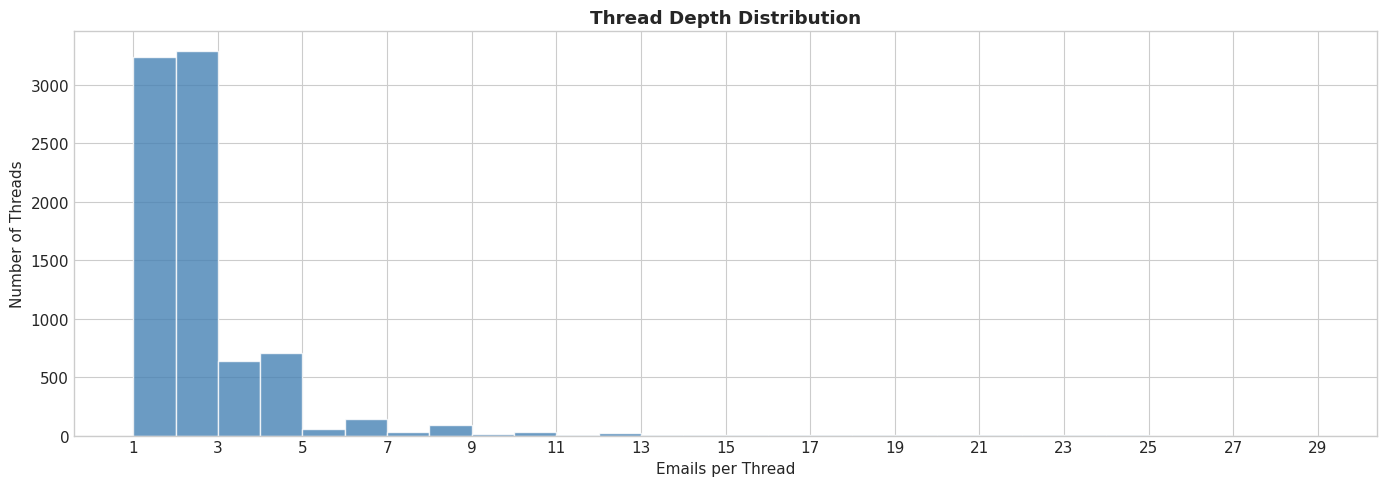

In [0]:
# ── Thread depth (emails per thread) ──
thread_depth = threads.select('email_count').toPandas()

print('Thread depth statistics:')
print(thread_depth.describe().to_string())
print(f"\nThreads with >5 emails: {(thread_depth['email_count'] > 5).sum()} ({100*(thread_depth['email_count'] > 5).mean():.1f}%)")
print(f"Threads with 1 email (singletons): {(thread_depth['email_count'] == 1).sum()} ({100*(thread_depth['email_count'] == 1).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(14, 5))
bins = list(range(1, min(thread_depth['email_count'].max()+2, 30)))
ax.hist(thread_depth['email_count'].clip(upper=30), bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Emails per Thread')
ax.set_ylabel('Number of Threads')
ax.set_title('Thread Depth Distribution', fontweight='bold')
ax.set_xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

Subject line stats:
 is_reply_or_fwd  count
            True   6747
           False  13253


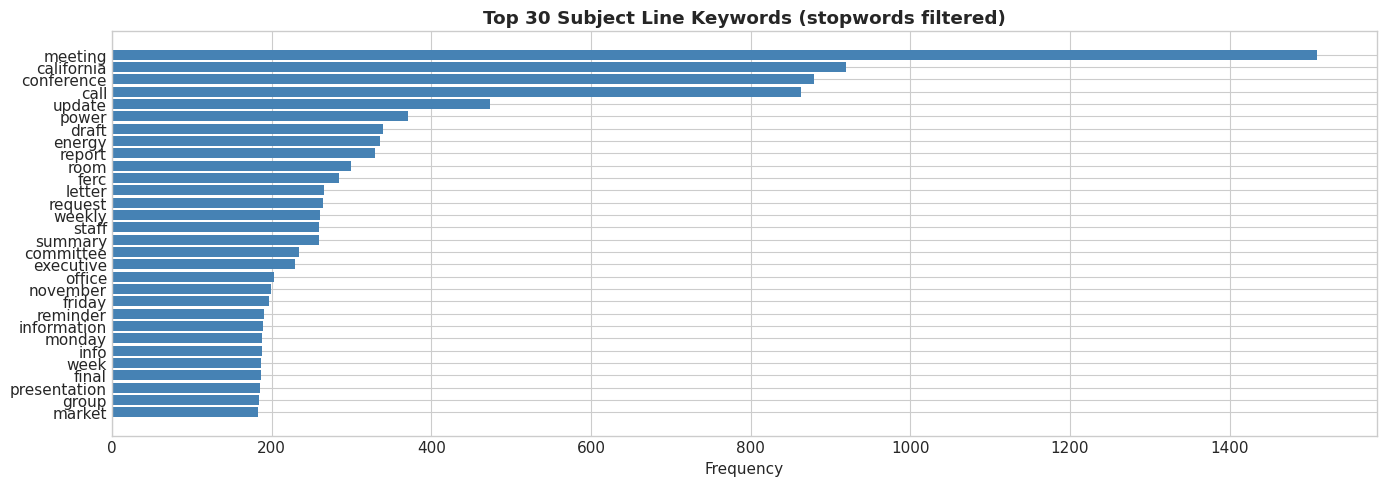

In [0]:
# ── Subject line patterns ──
subject_analysis = emails.select(
    F.lower(F.col('subject')).alias('subj_lower'),
    F.length('subject').alias('subj_len'),
    F.when(F.col('subject').rlike(r'^(?i)(re|fw|fwd)\s*:'), True).otherwise(False).alias('is_reply_or_fwd'),
)

print('Subject line stats:')
reply_fwd = subject_analysis.groupBy('is_reply_or_fwd').count().toPandas()
print(reply_fwd.to_string(index=False))

# Most common subject keywords (simple word frequency)
words_df = (
    emails
    .select(F.explode(F.split(F.lower(F.regexp_replace('subject', r'[^a-zA-Z\s]', '')), r'\s+')).alias('word'))
    .filter(F.length('word') > 3)
    .filter(~F.col('word').isin('enron', 'from', 'that', 'this', 'with', 'have', 'will', 'your', 'been', 'please', 'would', 'about'))
    .groupBy('word')
    .agg(F.count('*').alias('freq'))
    .orderBy(F.desc('freq'))
    .limit(30)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(words_df['word'][::-1], words_df['freq'][::-1], color='steelblue')
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Subject Line Keywords (stopwords filtered)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Recipient Patterns & Broadcasting Detection

Analyze TO/CC/BCC usage to distinguish 1-to-1 conversations from broadcasts
and mass-distribution emails. Heavy BCC usage may indicate political maneuvering.

Recipient count statistics:


summary,to_count,cc_count,bcc_count,total_recipients
count,20000,20000,20000,20000
mean,6.52535,1.51275,1.51275,9.55085
stddev,18.59156635935995,5.612317911800531,5.612317911800531,22.68514591246333
min,0,0,0,0
max,467,186,186,467


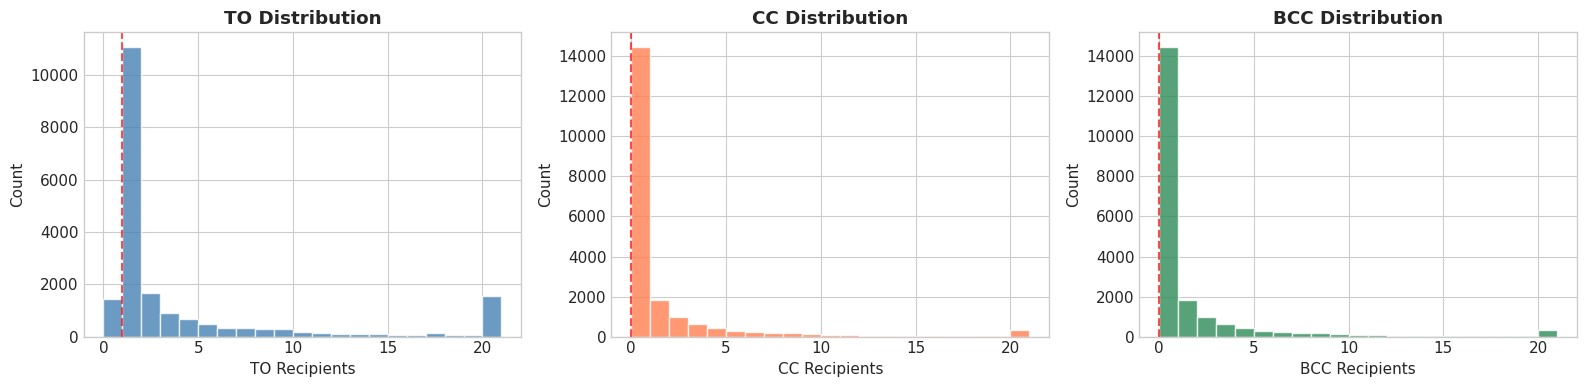

In [0]:
# ── TO, CC, BCC recipient count distributions ──
recipient_stats = (
    emails
    .select(
        F.size('to_recipients').alias('to_count'),
        F.size('cc_recipients').alias('cc_count'),
        F.size('bcc_recipients').alias('bcc_count'),
        (F.size('to_recipients') + F.size('cc_recipients') + F.size('bcc_recipients')).alias('total_recipients'),
    )
)

print('Recipient count statistics:')
display(recipient_stats.describe())

recip_pd = recipient_stats.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color, label in zip(
    axes,
    ['to_count', 'cc_count', 'bcc_count'],
    ['steelblue', 'coral', 'seagreen'],
    ['TO', 'CC', 'BCC']
):
    data = recip_pd[col].clip(upper=20)
    ax.hist(data, bins=range(0, 22), color=color, edgecolor='white', alpha=0.8)
    ax.set_xlabel(f'{label} Recipients')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.axvline(recip_pd[col].median(), color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [0]:
# ── Detect broadcast emails (high recipient count) ──
broadcast_threshold = 10
broadcasts = emails.filter(
    (F.size('to_recipients') + F.size('cc_recipients')) >= broadcast_threshold
)

print(f'Emails with >= {broadcast_threshold} total recipients: {broadcasts.count():,} ({100*broadcasts.count()/total:.1f}%)')
print(f'\nTop broadcast senders:')
display(
    broadcasts.groupBy('sender')
    .agg(F.count('*').alias('broadcast_count'))
    .orderBy(F.desc('broadcast_count'))
    .limit(15)
)

Emails with >= 10 total recipients: 3,406 (17.0%)

Top broadcast senders:


sender,broadcast_count
jeff.dasovich@enron.com,312
ginger.dernehl@enron.com,230
kay.chapman@enron.com,209
leonardo.pacheco@enron.com,77
lynn.blair@enron.com,72
ray.alvarez@enron.com,68
beverly.stephens@enron.com,64
sue.nord@enron.com,64
david.delainey@enron.com,61
carmen.perez@enron.com,58


In [0]:
# ── BCC analysis (potential political/sensitivity signals) ──
bcc_usage = emails.filter(F.size('bcc_recipients') > 0)
print(f'Emails with BCC: {bcc_usage.count():,} ({100*bcc_usage.count()/total:.1f}%)')
print(f'\nTop BCC users:')
display(
    bcc_usage.groupBy('sender')
    .agg(
        F.count('*').alias('bcc_email_count'),
        F.avg(F.size('bcc_recipients')).alias('avg_bcc_recipients'),
    )
    .orderBy(F.desc('bcc_email_count'))
    .limit(15)
)

Emails with BCC: 5,522 (27.6%)

Top BCC users:


sender,bcc_email_count,avg_bcc_recipients
jeff.dasovich@enron.com,615,5.923577235772358
david.delainey@enron.com,588,2.0799319727891157
lynn.blair@enron.com,319,2.761755485893417
kay.chapman@enron.com,259,14.965250965250965
joseph.alamo@enron.com,117,1.641025641025641
beverly.stephens@enron.com,104,6.538461538461538
owner-eveningmba@haas.berkeley.edu,86,2.7674418604651163
rosalee.fleming@enron.com,85,3.1411764705882352
ginger.dernehl@enron.com,82,11.24390243902439
leonardo.pacheco@enron.com,77,8.493506493506494


## 6. Executive Summary & GraphRAG Readiness

Key findings and recommendations for downstream knowledge graph extraction.

In [0]:
# ── Final summary for GraphRAG readiness ──
print('=' * 70)
print('ENRON EMAIL CORPUS — EDA EXECUTIVE SUMMARY')
print('=' * 70)

total_emails = emails.count()
total_threads = threads.count()
total_participants = participants.count()

rich_threads = threads.filter(F.col('email_count') >= 3).count()
avg_body = emails.agg(F.avg(F.length('body'))).collect()[0][0]
enron_domain = emails.filter(F.col('sender').contains('@enron.com')).count()

date_range = emails.agg(
    F.date_format(F.min('date'), 'yyyy-MM-dd').alias('min_date'),
    F.date_format(F.max('date'), 'yyyy-MM-dd').alias('max_date')
).collect()[0]

print(f"""
CORPUS DIMENSIONS
  Emails:         {total_emails:>10,}
  Participants:   {total_participants:>10,}
  Threads:        {total_threads:>10,}
  Date range:     {date_range[0]} → {date_range[1]}

CONTENT QUALITY
  Avg body length:          {avg_body:,.0f} chars
  Rich threads (>=3 emails): {rich_threads:,} ({100*rich_threads/total_threads:.1f}%)
  Enron-domain emails:       {enron_domain:,} ({100*enron_domain/total_emails:.1f}%)

GRAPHRAG READINESS
  ✓ Sufficient volume for entity extraction (20K emails)
  ✓ Multi-participant threads enable relationship discovery
  ✓ Temporal coverage spans full crisis period
  {'! High singleton thread rate — consider merging by subject similarity' if rich_threads/total_threads < 0.2 else '✓ Good thread depth for context windows'}
  {'! Consider filtering very short bodies (<50 chars)' if avg_body < 200 else '✓ Body length sufficient for NER'}
""")
print('=' * 70)

ENRON EMAIL CORPUS — EDA EXECUTIVE SUMMARY

CORPUS DIMENSIONS
  Emails:             20,000
  Participants:        8,380
  Threads:             8,301
  Date range:     0001-12-19 → 2002-09-22

CONTENT QUALITY
  Avg body length:          780 chars
  Rich threads (>=3 emails): 1,768 (21.3%)
  Enron-domain emails:       16,936 (84.7%)

GRAPHRAG READINESS
  ✓ Sufficient volume for entity extraction (20K emails)
  ✓ Multi-participant threads enable relationship discovery
  ✓ Temporal coverage spans full crisis period
  ✓ Good thread depth for context windows
  ✓ Body length sufficient for NER

